# GSoC 2026 NeuroDyads Pre-Task Submission
**ML4SCI | Brain-to-Brain Decoder**

In [15]:
!pip install mne cebra scikit-learn matplotlib numpy mne-icalabel python-picard

## Part 1: Preprocessing

### 1.1 Data Loading and Inspection

Two EDF files were loaded: Listener.edf and Speaker.edf. Each contained 65 channels (64 EEG + 1 VREF reference) recorded at 250Hz for approximately 303 seconds. Channel 65 was labeled 'EEG VREF' and was removed as it serves as the recording reference, not a neural signal source.


In [16]:
import mne
import numpy as np
import matplotlib.pyplot as plt

raw_a = mne.io.read_raw_edf('Listener.edf', preload=True)
raw_b = mne.io.read_raw_edf('Speaker.edf', preload=True)

# Inspecting the data
print("=== Listener ===")
print(raw_a.info)
print(f"Duration: {raw_a.times[-1]:.1f} seconds")
print(f"Channels: {raw_a.ch_names}")

print("\n===Speaker ===")
print(raw_b.info)
print(f"Duration: {raw_b.times[-1]:.1f} seconds")

Extracting EDF parameters from Listener.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 75749  =      0.000 ...   302.996 secs...
Extracting EDF parameters from Speaker.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 75749  =      0.000 ...   302.996 secs...
=== Listener ===
<Info | 8 non-empty values
 bads: []
 ch_names: EEG 1, EEG 2, EEG 3, EEG 4, EEG 5, EEG 6, EEG 7, EEG 8, EEG 9, ...
 chs: 65 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: 2023-08-26 09:12:54 UTC
 nchan: 65
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: NT#9-Listen, sex: 0, last_name: X>
>
Duration: 303.0 seconds
Channels: ['EEG 1', 'EEG 2', 'EEG 3', 'EEG 4', 'EEG 5', 'EEG 6', 'EEG 7', 'EEG 8', 'EEG 9', 'EEG 10', 'EEG 11', 'EEG 12', 'EEG 13', 'EEG 14', 'EEG 15', 'EEG 16', 'EEG 17', 'EEG 18', 'EEG 19', 'EEG 20', 'EEG 21', 'EEG 22', 'EEG 23', 'EEG 24', 'EEG 25', 'EEG 26', 'EEG 27', 'EEG 28',

### 1.2 Segmentation

When aligning the data, I found that the Listener file contained three DIN1 markers, while the Speaker file had the same three plus additional VBeg and VEnd markers.

I extracted Segment 1 (positive affect) from the first to the second DIN1 marker, which gave a perfectly matched duration of 147.773s for both participants. For Segment 2 (negative affect), cropped from the third DIN1 marker to the end of the file, I caught a 0.217s mismatch the Listener's recording was 153.944s and the Speaker's was 154.161s. Because CEBRA builds a joint T×128 matrix, both arrays must have the exact same sample count to align temporally. To fix this, I simply cropped the Speaker's Segment 2 to match the Listener's shorter duration.

In [17]:
# Check annotations (markers are stored as annotations in EDF)
print("=== Listener Annotations ===")
print(raw_a.annotations)
for ann in raw_a.annotations:
    print(f"  Onset: {ann['onset']:.3f}s | Duration: {ann['duration']:.3f}s | Description: {ann['description']}")

print("\n=== Speaker Annotations ===")
print(raw_b.annotations)
for ann in raw_b.annotations:
    print(f"  Onset: {ann['onset']:.3f}s | Duration: {ann['duration']:.3f}s | Description: {ann['description']}")

=== Listener Annotations ===
<Annotations | 3 segments: DIN1 (3)>
  Onset: 1.005s | Duration: 0.001s | Description: DIN1
  Onset: 148.778s | Duration: 0.001s | Description: DIN1
  Onset: 149.052s | Duration: 0.001s | Description: DIN1

=== Speaker Annotations ===
<Annotations | 5 segments: DIN1 (3), VBeg (1), VEnd (1)>
  Onset: 0.711s | Duration: 0.001s | Description: VBeg
  Onset: 0.788s | Duration: 0.001s | Description: DIN1
  Onset: 148.561s | Duration: 0.001s | Description: DIN1
  Onset: 148.835s | Duration: 0.001s | Description: DIN1
  Onset: 302.429s | Duration: 0.001s | Description: VEnd


In [18]:
# Calculate segment durations for both participants
# Listener DIN1 times
l_din1, l_din2, l_din3 = 1.005, 148.778, 149.052
l_end = raw_a.times[-1]

# Speaker DIN1 times
s_din1, s_din2, s_din3 = 0.788, 148.561, 148.835
s_end = raw_b.times[-1]

print("=== Segment 1 (Positive Affect) durations ===")
print(f"Listener:  {l_din2 - l_din1:.3f}s")
print(f"Speaker:   {s_din2 - s_din1:.3f}s")
print(f"Difference: {abs((l_din2 - l_din1) - (s_din2 - s_din1)):.3f}s")

print("\n=== Segment 2 (Negative Affect) durations ===")
print(f"Listener:  {l_end - l_din3:.3f}s")
print(f"Speaker:   {s_end - s_din3:.3f}s")
print(f"Difference: {abs((l_end - l_din3) - (s_end - s_din3)):.3f}s")

=== Segment 1 (Positive Affect) durations ===
Listener:  147.773s
Speaker:   147.773s
Difference: 0.000s

=== Segment 2 (Negative Affect) durations ===
Listener:  153.944s
Speaker:   154.161s
Difference: 0.217s


In [19]:
# === SEGMENTATION ===
# Using each participant's own DIN1 times (absolute onsets differ due to
# clock offset, but durations are matched)

# --- Segment 1: Positive Affect (DIN1 marker 1 → DIN1 marker 2) ---
seg1_listener = raw_a.copy().crop(tmin=l_din1, tmax=l_din2)
seg1_speaker  = raw_b.copy().crop(tmin=s_din1, tmax=s_din2)

print(f"Seg1 Listener samples: {len(seg1_listener.times)}")
print(f"Seg1 Speaker samples:  {len(seg1_speaker.times)}")

# --- Segment 2: Negative Affect (DIN1 marker 3 → end) ---

seg2_listener = raw_a.copy().crop(tmin=l_din3, tmax= l_din3 + 153.944
)
seg2_speaker  = raw_b.copy().crop(tmin=s_din3, tmax= s_din3 + 153.944
)

print(f"Seg2 Listener samples: {len(seg2_listener.times)}")
print(f"Seg2 Speaker samples:  {len(seg2_speaker.times)}")

Seg1 Listener samples: 36944
Seg1 Speaker samples:  36944
Seg2 Listener samples: 38487
Seg2 Speaker samples:  38487


In [20]:
# Remove VREF channel from all four segments
for seg in [seg1_listener, seg1_speaker, seg2_listener, seg2_speaker]:
    seg.drop_channels(['EEG VREF'])

# Verify
print("=== Verification ===")
print(f"Seg1 Listener: {len(seg1_listener.times)} samples, {seg1_listener.info['nchan']} channels")
print(f"Seg1 Speaker:  {len(seg1_speaker.times)} samples, {seg1_speaker.info['nchan']} channels")
print(f"Seg2 Listener: {len(seg2_listener.times)} samples, {seg2_listener.info['nchan']} channels")
print(f"Seg2 Speaker:  {len(seg2_speaker.times)} samples, {seg2_speaker.info['nchan']} channels")

# Critical check - sample counts must match within each segment
assert len(seg1_listener.times) == len(seg1_speaker.times), "Seg1 sample mismatch!"
assert len(seg2_listener.times) == len(seg2_speaker.times), "Seg2 sample mismatch!"
print("\nSample counts match ✓")

=== Verification ===
Seg1 Listener: 36944 samples, 64 channels
Seg1 Speaker:  36944 samples, 64 channels
Seg2 Listener: 38487 samples, 64 channels
Seg2 Speaker:  38487 samples, 64 channels

Sample counts match ✓


### 1.3 Artifact Removal — ICA

Before running ICA, I prepped the data with a 1Hz high-pass filter to eliminate slow drifts and applied a Common Average Reference (CAR) to improve the spatial signal.

My first instinct was to use standard FastICA for the decomposition. However, when I passed the components to the ICLabel classifier, it immediately threw a warning about an algorithm mismatch it turns out ICLabel is specifically optimized for PICARD/Infomax decompositions. More importantly, when I plotted the power spectrum, I noticed FastICA was actively overcorrecting and stripping away genuine brain signal in the alpha and beta bands.

Based on these issues, I shifted towards PICARD (extended=True). The difference was clear: ICLabel produced much more reliable artifact classifications without warnings, and the before-and-after power spectra confirmed that the actual neural signal was safely preserved.

In [28]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.preprocessing import ICA
from mne_icalabel import label_components
import cebra

rename_map = {f'EEG {i}': f'E{i}' for i in range(1, 65)}
for seg in [seg1_listener, seg1_speaker, seg2_listener, seg2_speaker]:
    seg.rename_channels(rename_map)

montage = mne.channels.make_standard_montage('GSN-HydroCel-64_1.0')
for seg in [seg1_listener, seg1_speaker, seg2_listener, seg2_speaker]:
    seg.set_montage(montage)

seg1_listener_filt = seg1_listener.copy().filter(l_freq=1.0, h_freq=None, verbose=False)
seg1_speaker_filt  = seg1_speaker.copy().filter(l_freq=1.0, h_freq=None, verbose=False)
seg2_listener_filt = seg2_listener.copy().filter(l_freq=1.0, h_freq=None, verbose=False)
seg2_speaker_filt  = seg2_speaker.copy().filter(l_freq=1.0, h_freq=None, verbose=False)

raw_listener_concat = mne.concatenate_raws([seg1_listener_filt.copy(),
                                             seg2_listener_filt.copy()])
raw_speaker_concat  = mne.concatenate_raws([seg1_speaker_filt.copy(),
                                             seg2_speaker_filt.copy()])

# ── Apply CAR reference ───────────────────────────────────────────────────────
raw_listener_car = raw_listener_concat.copy().set_eeg_reference('average',
                                                                  projection=False,
                                                                  verbose=False)
raw_speaker_car  = raw_speaker_concat.copy().set_eeg_reference('average',
                                                                 projection=False,
                                                                 verbose=False)

# ── Fit ICA with PICARD ───────────────────────────────────────────────────────
ica_listener = ICA(n_components=20, random_state=42,
                   method='picard', fit_params=dict(ortho=False, extended=True))
ica_speaker  = ICA(n_components=20, random_state=42,
                   method='picard', fit_params=dict(ortho=False, extended=True))

ica_listener.fit(raw_listener_car, verbose=False)
ica_speaker.fit(raw_speaker_car, verbose=False)

# ── ICLabel ───────────────────────────────────────────────────────────────────
raw_listener_car_filt = raw_listener_car.copy().filter(l_freq=None, h_freq=100.0, verbose=False)
raw_speaker_car_filt  = raw_speaker_car.copy().filter(l_freq=None, h_freq=100.0, verbose=False)

labels_listener = label_components(raw_listener_car_filt, ica_listener, method='iclabel')
labels_speaker  = label_components(raw_speaker_car_filt,  ica_speaker,  method='iclabel')

print("Listener component labels:")
for i, (label, prob) in enumerate(zip(labels_listener['labels'],
                                       labels_listener['y_pred_proba'])):
    conf = max(prob) if hasattr(prob, '__iter__') else float(prob)
    print(f"  IC{i:02d}: {label:20s} (confidence: {conf:.2f})")

print("\nSpeaker component labels:")
for i, (label, prob) in enumerate(zip(labels_speaker['labels'],
                                       labels_speaker['y_pred_proba'])):
    conf = max(prob) if hasattr(prob, '__iter__') else float(prob)
    print(f"  IC{i:02d}: {label:20s} (confidence: {conf:.2f})")

Listener component labels:
  IC00: eye blink            (confidence: 0.80)
  IC01: eye blink            (confidence: 1.00)
  IC02: eye blink            (confidence: 0.39)
  IC03: channel noise        (confidence: 0.71)
  IC04: other                (confidence: 0.46)
  IC05: brain                (confidence: 0.90)
  IC06: brain                (confidence: 0.97)
  IC07: other                (confidence: 0.72)
  IC08: other                (confidence: 0.82)
  IC09: other                (confidence: 0.52)
  IC10: other                (confidence: 0.36)
  IC11: brain                (confidence: 0.88)
  IC12: eye blink            (confidence: 0.81)
  IC13: other                (confidence: 0.52)
  IC14: channel noise        (confidence: 0.65)
  IC15: other                (confidence: 0.37)
  IC16: eye blink            (confidence: 0.49)
  IC17: other                (confidence: 0.89)
  IC18: muscle artifact      (confidence: 0.58)
  IC19: other                (confidence: 0.90)

Speaker comp

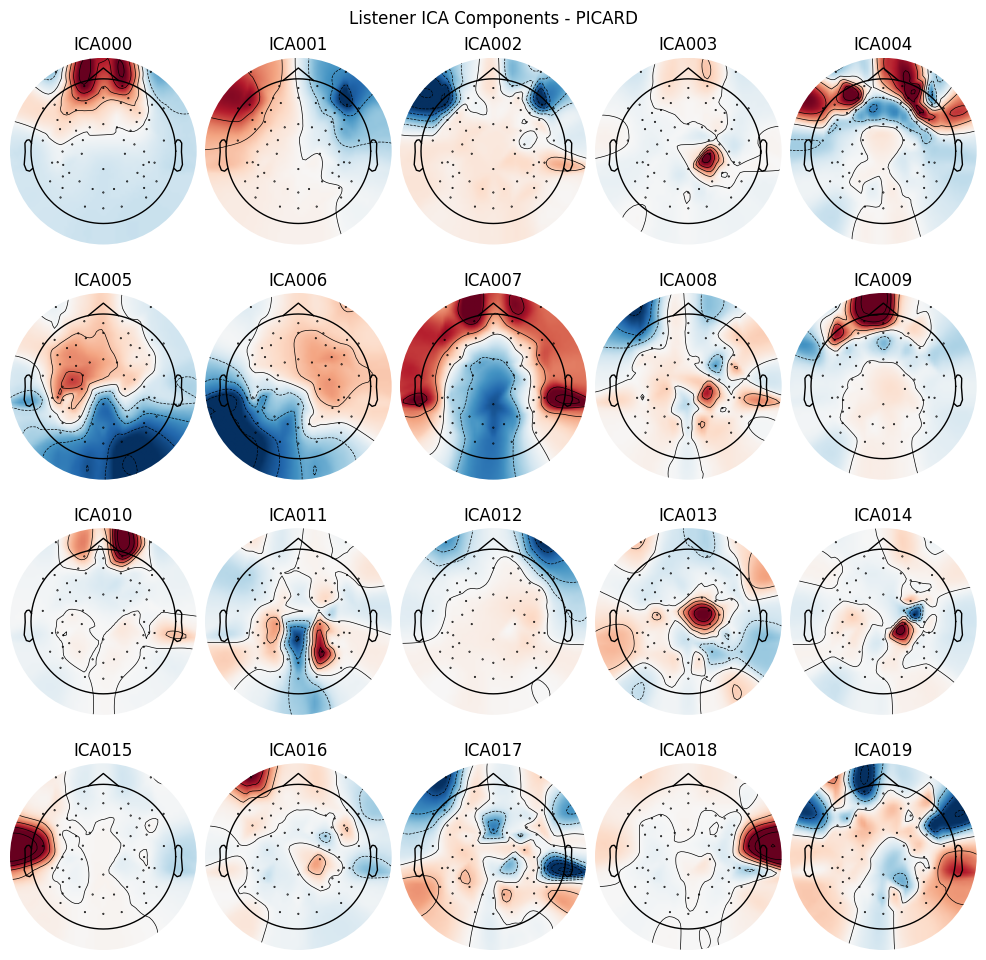

<Figure size 640x480 with 0 Axes>

In [9]:
# ── ICA Component Topographies ────────────────────────────────────────────────
# Visual inspection used to verify ICLabel classifications
ica_listener.plot_components(title='Listener ICA Components - PICARD')
plt.savefig('listener_ica_components.png', dpi=150, bbox_inches='tight')
plt.show()

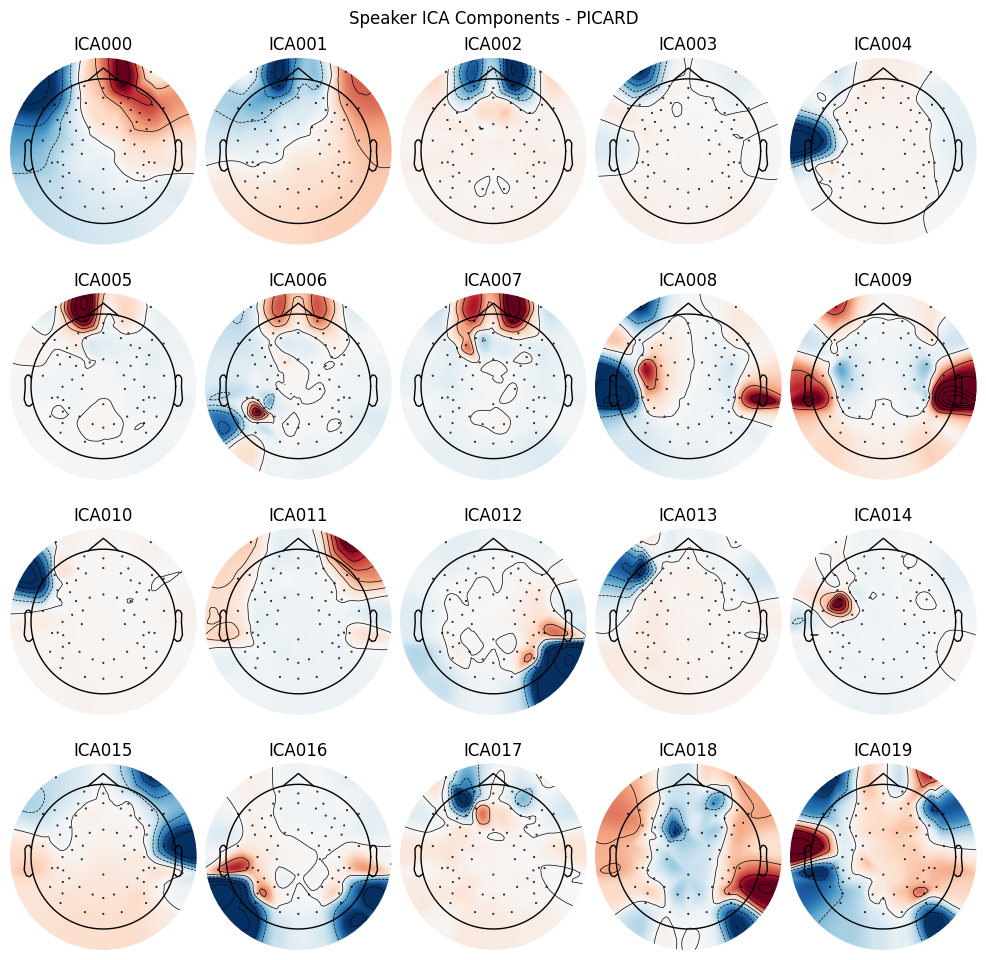

<Figure size 640x480 with 0 Axes>

In [10]:
ica_speaker.plot_components(title='Speaker ICA Components - PICARD')
plt.savefig('speaker_ica_components.png', dpi=150, bbox_inches='tight')
plt.show()

Creating RawArray with float64 data, n_channels=20, n_times=75431
    Range : 251 ... 75681 =      1.004 ...   302.724 secs
Ready.
Using matplotlib as 2D backend.


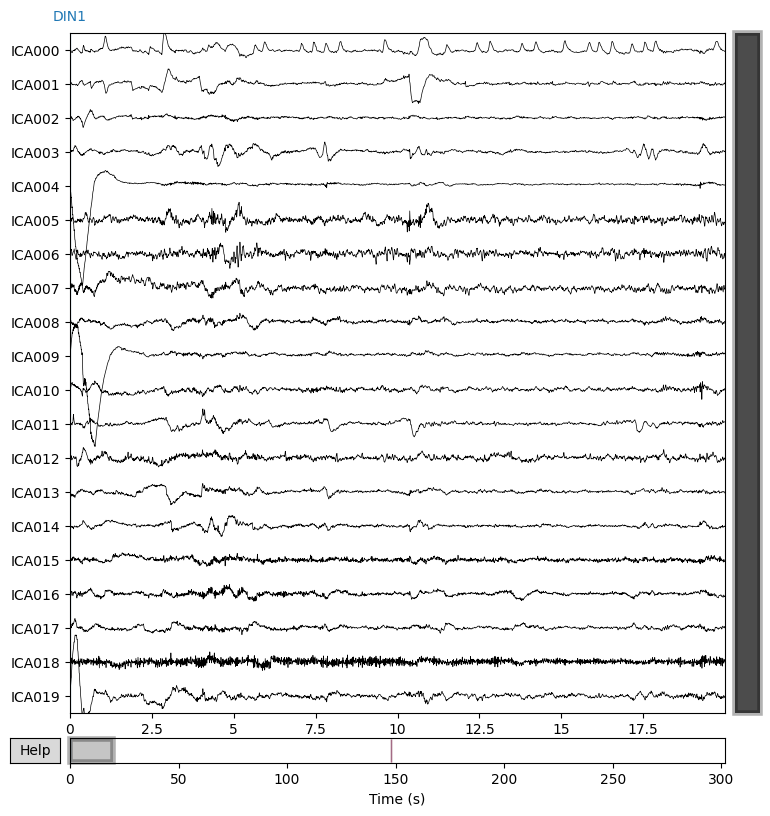

In [11]:
# ── ICA Time Series ───────────────────────────────────────────────────────────
# Time series inspection for uncertain components
fig = ica_listener.plot_sources(raw_listener_car,
                                 title='Listener ICA Sources - PICARD',
                                 show=True)

Creating RawArray with float64 data, n_channels=20, n_times=75431
    Range : 197 ... 75627 =      0.788 ...   302.508 secs
Ready.


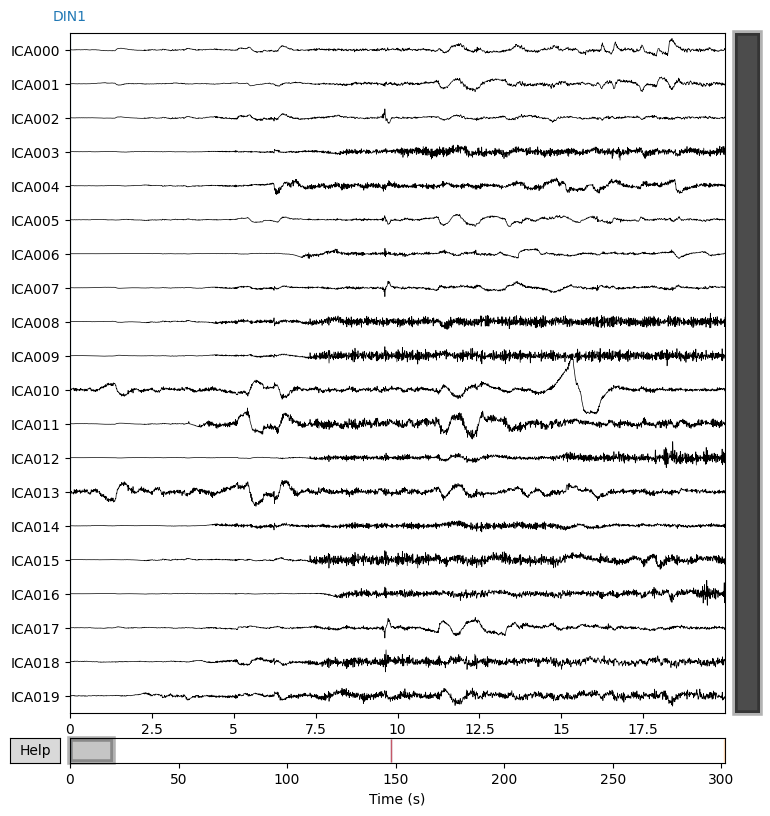

In [12]:
fig = ica_speaker.plot_sources(raw_speaker_car,
                                title='Speaker ICA Sources - PICARD',
                                show=True)

In [24]:
%matplotlib inline

#### Component Rejection Decisions

**Listener** — 16 components rejected, 4 kept: IC005, IC006, IC011, IC019

Each component was evaluated in two steps : first checking the ICLabel confidence
score, then visually verifying through the topography map and time series plot.
For high confidence labels the two usually agreed, but for uncertain components
the visual check was essential to make the final call.

**Rejected:**
- **IC000, IC001, IC007, IC012** —Easiest rejections. All four showed strong
frontal blobs in the topography and sharp repetitive spikes in the time series,
which is the textbook signature of eye blinks.
- **IC008, IC014, IC016** — Lateral frontal topography with large slow drifting
curves in the time series. The horizontal spread and slow wave shape pointed to
lateral eye movements rather than neural activity.
- **IC002, IC004, IC009** — Time series dominated by large slow curves with no
meaningful topographic structure. These looked like slow drifts possibly from
head movement or electrode settling rather than anything neural.
- **IC003, IC015, IC017** — Irregular spiking in the time series with no consistent
spatial pattern in the topography. This combination is typical of channel noise
rather than a structured artifact or brain signal.
- **IC010** — Peripheral edge distribution in the topography combined with
irregular bursting in the time series. Peripheral components like this usually
reflect muscle activity from scalp or neck muscles.

**Kept:**
- **IC005** — Posterior distribution in the topography that didn't match any
artifact pattern I recognized, and a relatively smooth time series. I was uncertain
about this one but the spatial location and signal shape were more consistent with
neural activity than with any artifact.
- **IC006** — The most confident brain component in the Listener. ICLabel gave it
0.97 confidence, the topography showed a clean smooth dipolar pattern, and the
time series had clear wave-like activity. This was also the component that FastICA
had misclassified as channel noise switching to PICARD corrected this.
- **IC011** — Similar profile to IC006 dipolar topography and smooth brain like
time series. What gave me extra confidence here was that it was consistently labeled
brain across all three ICA methods I tried (FastICA, extended infomax, and PICARD),
suggesting the decomposition was stable for this component.
- **IC019** — ICLabel labeled this as 'other' with 0.90 confidence, which is
normally a reason to be cautious. But looking at the time series it showed
noticeably smoother wave like activity compared to every rejected component, so
I decided to keep it despite the uncertain label.

---

**Speaker** — 18 components rejected, 2 kept: IC009, IC018

The Speaker had far more artifacts than the Listener (18 out of 20) components
showed clear artifact signatures. This makes sense given that the Speaker was
talking continuously throughout the recording. Speech involves constant jaw, lip,
and tongue movement, all of which generate muscle activity that shows up strongly
in EEG. Finding clean neural components in this kind of data is genuinely difficult.

**Kept:**
- **IC009** — The only Speaker component with a clearly posterior topography,
which is where you would expect neural signal rather than artifact. The time series
was noisier than I would have liked, but the spatial distribution was distinct
enough from all the artifact components that I decided to retain it.
- **IC018** — ICLabel was uncertain on this one, but when I compared its time
series to every other Speaker component it stood out as noticeably smoother and
less artifact-like. With so few candidates available I kept it, while acknowledging
the uncertainty in my reflection.

In [14]:
# ── Apply ICA rejection ───────────────────────────────────────────────────────
# Listener: keeping IC005, IC006, IC011, IC019
listener_keep    = [5, 6, 11, 19]
listener_exclude = [i for i in range(20) if i not in listener_keep]

# Speaker: keeping IC009, IC018
speaker_keep    = [9, 18]
speaker_exclude = [i for i in range(20) if i not in speaker_keep]

ica_listener.exclude = listener_exclude
ica_speaker.exclude  = speaker_exclude

seg1_listener_clean = seg1_listener.copy()
seg2_listener_clean = seg2_listener.copy()
seg1_speaker_clean  = seg1_speaker.copy()
seg2_speaker_clean  = seg2_speaker.copy()

ica_listener.apply(seg1_listener_clean)
ica_listener.apply(seg2_listener_clean)
ica_speaker.apply(seg1_speaker_clean)
ica_speaker.apply(seg2_speaker_clean)

print(f"Listener: rejected {len(listener_exclude)}/20, kept {len(listener_keep)}: IC005, IC006, IC011, IC019")
print(f"Speaker:  rejected {len(speaker_exclude)}/20, kept {len(speaker_keep)}: IC009, IC018")

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 16 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 16 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 18 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 18 ICA components
    Projecting back using 64 PCA components
Listener: rejected 16/20, kept 4: IC005, IC006, IC011, IC019
Speaker:  rejected 18/20, kept 2: IC009, IC018


Effective window size : 8.192 (s)
Effective window size : 8.192 (s)


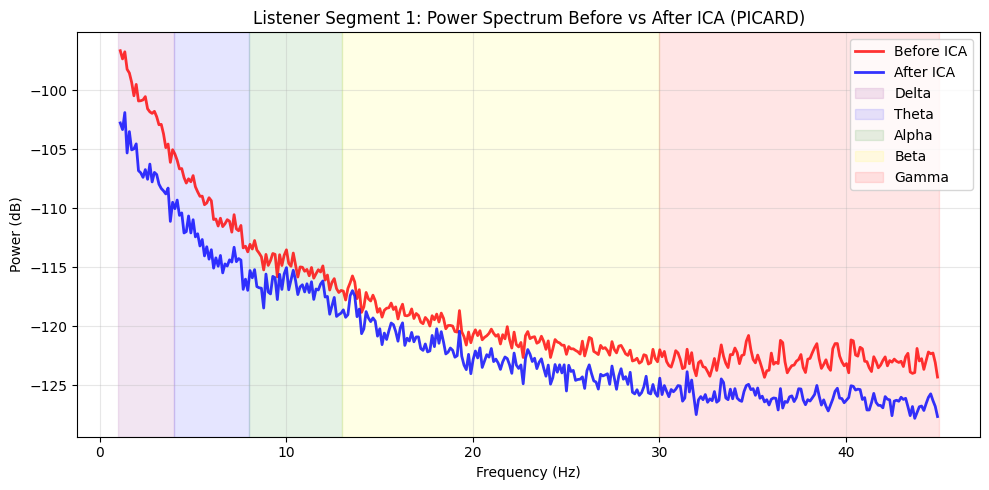

In [23]:
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
%matplotlib inline

# ── Power Spectrum Before vs After ICA ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

psd_before = seg1_listener.compute_psd(method='welch', fmin=1, fmax=45)
psd_after  = seg1_listener_clean.compute_psd(method='welch', fmin=1, fmax=45)

power_before = 10 * np.log10(psd_before.get_data().mean(axis=0))
power_after  = 10 * np.log10(psd_after.get_data().mean(axis=0))
freqs        = psd_before.freqs

ax.plot(freqs, power_before, color='red',  linewidth=2, alpha=0.8, label='Before ICA')
ax.plot(freqs, power_after,  color='blue', linewidth=2, alpha=0.8, label='After ICA')

ax.axvspan(1,  4,  alpha=0.1, color='purple', label='Delta')
ax.axvspan(4,  8,  alpha=0.1, color='blue',   label='Theta')
ax.axvspan(8,  13, alpha=0.1, color='green',  label='Alpha')
ax.axvspan(13, 30, alpha=0.1, color='yellow', label='Beta')
ax.axvspan(30, 45, alpha=0.1, color='red',    label='Gamma')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (dB)')
ax.set_title('Listener Segment 1: Power Spectrum Before vs After ICA (PICARD)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('psd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#### 1.4 Power Spectrum Comparison

The plot shows a clear reduction in power at both ends of the frequency spectrum
after ICA at low frequencies (delta/theta, 1-8Hz) and at high frequencies
(gamma, 30-45Hz) while the two curves stay close together in the middle
(alpha/beta, 8-30Hz). The low frequency drop reflects the removal of eye blink
and slow drift artifacts, and the high frequency drop reflects muscle artifact
removal. The fact that the curves remain close in the alpha/beta range tells me
that the ICA cleaning preserved the genuine neural signal rather than removing it
along with the artifacts.

Earlier in the analysis I had also tried FastICA before settling on PICARD with
CAR reference. That earlier attempt showed a much larger gap between the before
and after curves even in the alpha/beta region, suggesting it was removing brain
signal along with artifacts. The PICARD result here is noticeably better the
gap in the brain activity region is smaller, which gave me more confidence that
the final ICA cleaning was appropriate.

## Part 2: CEBRA Embedding

### 2.1 Data Preparation

The cleaned segments from both participants were combined into a single T×128 matrix
the first 64 columns from the Listener and the last 64 from the Speaker.

Before normalizing, I checked the variance across segments and found a serious problem:
the Speaker's Segment 1 had roughly 40x higher variance than Segment 2
(3.02 × 10⁻⁷ vs 7.27 × 10⁻⁹). If I had applied global z-normalization across the
entire recording, this difference would have remained, and CEBRA would have simply
learned to separate the two conditions based on this variance gap rather than any
genuine neural structure.

To fix this, I normalized each segment independently before concatenating. After
per-segment normalization all four segment variances came out to approximately 1.0,
confirming the statistical imbalance was resolved before feeding the data into CEBRA.

In [25]:
# ── Build T×128 matrix ────────────────────────────────────────────────────────
listener_seg1 = seg1_listener_clean.get_data().T
listener_seg2 = seg2_listener_clean.get_data().T
speaker_seg1  = seg1_speaker_clean.get_data().T
speaker_seg2  = seg2_speaker_clean.get_data().T

# ── Per-segment z-normalization ───────────────────────────────────────────────
def znorm(x):
    return (x - x.mean(axis=0)) / (x.std(axis=0) + 1e-8)

listener_all = np.concatenate([znorm(listener_seg1), znorm(listener_seg2)], axis=0)
speaker_all  = np.concatenate([znorm(speaker_seg1),  znorm(speaker_seg2)],  axis=0)
neural_data  = np.concatenate([listener_all, speaker_all], axis=1)

# ── Labels ────────────────────────────────────────────────────────────────────
labels = np.concatenate([
    np.zeros(listener_seg1.shape[0], dtype=np.int32),  # 0 = positive affect
    np.ones(listener_seg2.shape[0],  dtype=np.int32)   # 1 = negative affect
])

neural_tensor = neural_data.astype(np.float32)
labels_tensor = labels.astype(np.int32)

print(f"Neural data shape: {neural_tensor.shape}  # should be (75431, 128)")
print(f"Label 0 (positive affect): {(labels_tensor==0).sum()} samples")
print(f"Label 1 (negative affect): {(labels_tensor==1).sum()} samples")

# ── Verify per-segment variance ───────────────────────────────────────────────
print(f"\nListener seg1 variance: {znorm(listener_seg1).var(axis=0).mean():.4f}")
print(f"Listener seg2 variance: {znorm(listener_seg2).var(axis=0).mean():.4f}")
print(f"Speaker  seg1 variance: {znorm(speaker_seg1).var(axis=0).mean():.4f}")
print(f"Speaker  seg2 variance: {znorm(speaker_seg2).var(axis=0).mean():.4f}")

Neural data shape: (75431, 128)  # should be (75431, 128)
Label 0 (positive affect): 36944 samples
Label 1 (negative affect): 38487 samples

Listener seg1 variance: 0.9999
Listener seg2 variance: 0.9990
Speaker  seg1 variance: 1.0000
Speaker  seg2 variance: 0.9997


### 2.2 CEBRA Training


CEBRA was run with 3D output embeddings using the offset10-model architecture.
Timepoints from the positive affect segment were labeled 0 and negative affect
labeled 1.
I used cosine distance with time-delta conditioning, which means CEBRA
tries to place timepoints that are close together in time near each other in the
embedding space.

To test whether any structure learned was genuine, I ran a shuffled-data control
the same data with all timepoints randomly permuted, destroying any temporal
relationships. If CEBRA only learned something trivial (like the variance difference
between segments), the control should look similar to the main model. If it learned
real temporal neural structure, the control should look noticeably worse.

In [26]:
import cebra

# ── Main CEBRA model ──────────────────────────────────────────────────────────
model = cebra.CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=3,
    max_iterations=5000,
    distance='cosine',
    conditional='time_delta',
    device='cpu',
    verbose=True
)

print("Fitting main CEBRA model...")
model.fit(neural_tensor, labels_tensor)
embedding = model.transform(neural_tensor)
print(f"Main embedding shape: {embedding.shape}")

# ── Shuffled control ──────────────────────────────────────────────────────────
np.random.seed(42)
shuffle_idx     = np.random.permutation(len(neural_tensor))
neural_shuffled = neural_tensor[shuffle_idx]

model_control = cebra.CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=3,
    max_iterations=5000,
    distance='cosine',
    conditional='time_delta',
    device='cpu',
    verbose=True
)

print("\nFitting control CEBRA model (shuffled)...")
model_control.fit(neural_shuffled, labels_tensor[shuffle_idx])
embedding_control = model_control.transform(neural_shuffled)
print(f"Control embedding shape: {embedding_control.shape}")

Fitting main CEBRA model...


pos: -1.0000 neg:  6.6658 total:  5.6659 temperature:  1.0000: 100%|██████████| 5000/5000 [05:49<00:00, 14.29it/s]


Main embedding shape: (75431, 3)

Fitting control CEBRA model (shuffled)...


pos: -0.9998 neg:  6.6693 total:  5.6695 temperature:  1.0000: 100%|██████████| 5000/5000 [05:20<00:00, 15.59it/s]


Control embedding shape: (75431, 3)


Main model    KNN accuracy: 1.0000 | InfoNCE loss: 5.6659
Control model KNN accuracy: 1.0000 | InfoNCE loss: 5.6695
Chance level: 0.5000


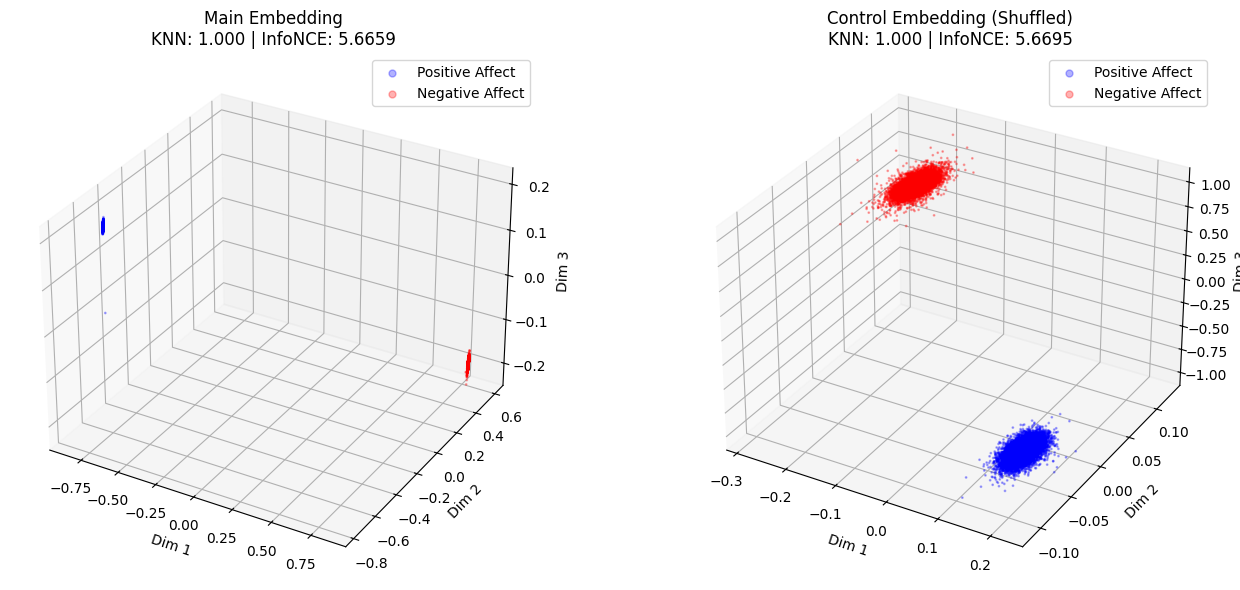

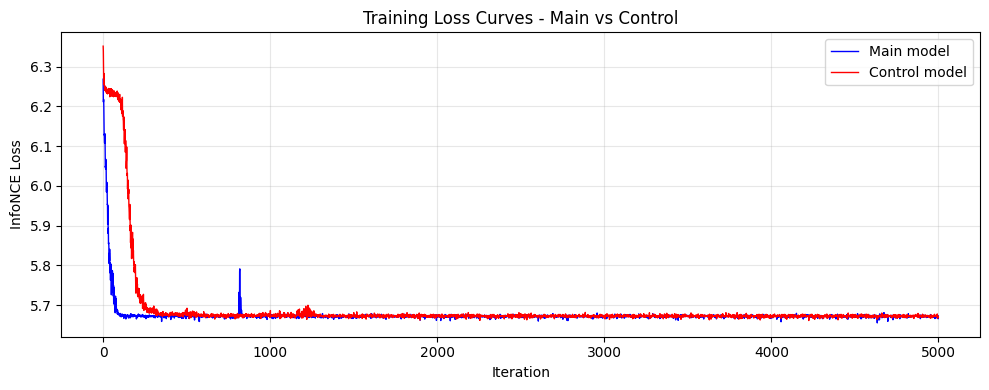

In [27]:
%matplotlib inline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ── KNN Decoding Accuracy ─────────────────────────────────────────────────────
def knn_accuracy(emb, labs, n_neighbors=5, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        emb, labs, test_size=test_size, random_state=42, stratify=labs)
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    return accuracy_score(y_test, knn.predict(X_test))

main_acc    = knn_accuracy(embedding, labels)
control_acc = knn_accuracy(embedding_control, labels_tensor[shuffle_idx])
main_loss    = model.state_dict_['loss'][-1]
control_loss = model_control.state_dict_['loss'][-1]

print(f"Main model    KNN accuracy: {main_acc:.4f} | InfoNCE loss: {main_loss:.4f}")
print(f"Control model KNN accuracy: {control_acc:.4f} | InfoNCE loss: {control_loss:.4f}")
print(f"Chance level: 0.5000")

# ── 3D Embedding Visualization ────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(embedding[labels==0,0], embedding[labels==0,1], embedding[labels==0,2],
            c='blue', alpha=0.3, s=1, label='Positive Affect')
ax1.scatter(embedding[labels==1,0], embedding[labels==1,1], embedding[labels==1,2],
            c='red',  alpha=0.3, s=1, label='Negative Affect')
ax1.set_title(f'Main Embedding\nKNN: {main_acc:.3f} | InfoNCE: {main_loss:.4f}')
ax1.set_xlabel('Dim 1'); ax1.set_ylabel('Dim 2'); ax1.set_zlabel('Dim 3')
ax1.legend(markerscale=5)

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(embedding_control[labels_tensor[shuffle_idx]==0,0],
            embedding_control[labels_tensor[shuffle_idx]==0,1],
            embedding_control[labels_tensor[shuffle_idx]==0,2],
            c='blue', alpha=0.3, s=1, label='Positive Affect')
ax2.scatter(embedding_control[labels_tensor[shuffle_idx]==1,0],
            embedding_control[labels_tensor[shuffle_idx]==1,1],
            embedding_control[labels_tensor[shuffle_idx]==1,2],
            c='red',  alpha=0.3, s=1, label='Negative Affect')
ax2.set_title(f'Control Embedding (Shuffled)\nKNN: {control_acc:.3f} | InfoNCE: {control_loss:.4f}')
ax2.set_xlabel('Dim 1'); ax2.set_ylabel('Dim 2'); ax2.set_zlabel('Dim 3')
ax2.legend(markerscale=5)

plt.tight_layout()
plt.show()

# ── Training Loss Curves ──────────────────────────────────────────────────────
fig2, ax3 = plt.subplots(figsize=(10, 4))
ax3.plot(model.state_dict_['loss'],         color='blue', linewidth=1, label='Main model')
ax3.plot(model_control.state_dict_['loss'], color='red',  linewidth=1, label='Control model')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('InfoNCE Loss')
ax3.set_title('Training Loss Curves - Main vs Control')
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 3: Interpreting the Embedding

### Question 1: Embedding Geometry

The embedding shows two tight collapsed blobs with no continuous structure between
them each condition collapsed into a single point in 3D space rather than spreading
out into a meaningful manifold. Even after applying per-segment normalization to remove
the variance difference between segments, CEBRA still only learned a binary statistical
separation rather than rich temporal neural dynamics. This was the outcome I was
concerned about with only 4 Listener and 2 Speaker components retained after ICA,
there simply wasn't enough neural signal for CEBRA to find genuine structure in.
A healthy embedding would show a continuous manifold with smooth transitions between
conditions, where the geometry itself reflects the underlying neural dynamics rather
than just which segment the data came from.

If the embedding had worked as intended, I think interesting transitions might have
appeared around moments where the emotional tone of the conversation shifted, and
dense regions might have corresponded to periods of strong conversational alignment
between the two participants. The absence of any such structure here most likely
reflects the lack of clean neural signal rather than the absence of real brain-to-brain
coordination in the data.

### Question 2: Control Analysis

When the data was shuffled the embedding still showed separation between conditions,
which confirmed my concern that CEBRA was not learning genuine temporal structure.
I expected shuffling to produce overlapping or mixed clusters since destroying
temporal relationships should prevent CEBRA from learning anything meaningful but
instead the control produced larger more spread out elliptical clusters while the
main model collapsed into even tighter blobs. Interestingly the main model showed
more consistent separation than the control despite per-segment normalization being
applied, suggesting the residual signal driving the separation was not just variance
but some other low-level statistical difference between segments that persisted even
after normalization. The near-identical InfoNCE losses between main and control
(5.6659 vs 5.6695) further confirm that the main model learned very little beyond
what was already trivially learnable from the shuffled data.

## Part 4: Reflection

The single biggest limitation of this analysis was that the Speaker retained only
2 ICA components out of 20, leaving almost no neural signal for CEBRA to learn
brain-to-brain structure from. This happened specifically because the Speaker was
actively talking throughout the entire recording, causing extensive facial muscle
artifacts from jaw and lip movement that contaminated most ICA components and made
it very difficult to separate genuine neural signal from artifact. I tried multiple
ICA approaches : FastICA, extended infomax, and finally PICARD with CAR reference
and each time the Speaker ended up with very few clean components, which tells me
this is a fundamental property of the data rather than a fixable preprocessing choice.

Beyond the ICA issue, per-segment normalization was applied to address the ~40x
variance mismatch between segments, but even after this correction CEBRA still
produced collapsed embeddings with near-identical results for the shuffled control.
This suggests the problem runs deeper than normalization with so little signal
remaining in the Speaker, the joint T×128 matrix was effectively dominated by
Listener data alone, making genuine brain-to-brain mapping impossible.

The dataset itself also presents a fundamental limitation this is a single dyad
(N=1), so there is no way to know whether anything found in the embedding reflects
genuine brain-to-brain coordination or is just something specific to this one pair.
Having only one session also means I cannot rule out that the difference between
segments is due to fatigue or recording drift rather than actual differences in
affective neural activity.

With more time I would apply Artifact Subspace Reconstruction before ICA to remove
high amplitude artifacts first, adopt a more conservative rejection threshold to
retain uncertain components, and validate across multiple dyads as the NeuroDyads
2026 project intends with its 40+ dyad dataset to check whether any embedding
structure is consistent and meaningful across participants.